# **Step2. Multi-label 분류**



**미션 : 리뷰에 포함된 11가지 속성을 검출하기(Multi-label Multi-Classification)**

1) 목표 : 리뷰 내용에서, 속성에 해당하는 내용이 등장하는지 분류하는
모델 생성
2) 절차
    * 데이터 전처리 : 주어진 데이터를 목표에 맞는 형태로 변환
    * 모델링 : 다중 레이블 분류 파인 튜닝
        * 일반 파인 튜닝
        * LoRA 파인 튜닝

## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [1]:
!pip install datasets peft accelerate -q

In [2]:
# (Colab) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
!apt -qq -y install fonts-nanum > /dev/null
!rm -rf ~/.cache/matplotlib

import matplotlib as mpl
import matplotlib.font_manager as fm
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

In [3]:
# 한글폰트 설치
import matplotlib as mpl
import matplotlib.font_manager as fm

%config InlineBackend.figure_format = 'retina'
!apt -qq -y install fonts-nanum

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import torch

from transformers import Trainer, TrainingArguments, EarlyStoppingCallback, AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

from peft import get_peft_model, LoraConfig, TaskType

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

### (2) GPU 설정
* GPU 사용을 위한 설정

In [5]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2.데이터 준비

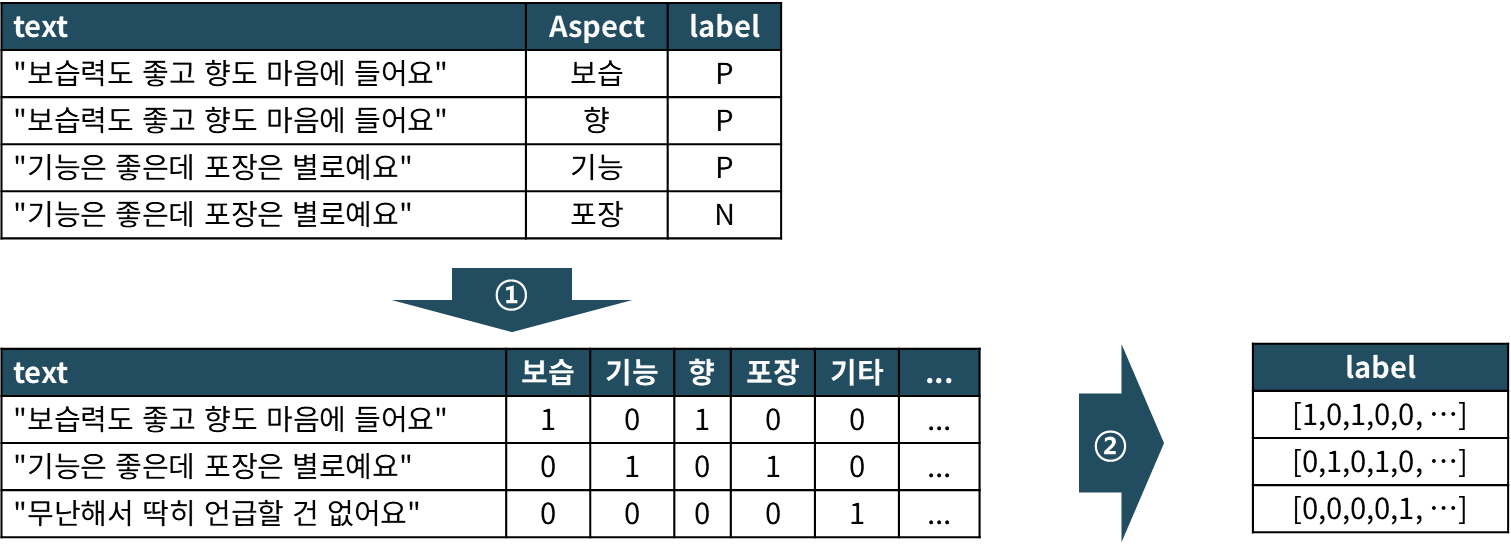

### (1) 데이터 로딩
* data.csv 파일 로딩

In [6]:
# 파일 업로드
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [7]:
df = pd.read_csv("data.csv")

### (2) Dataset 준비1

In [8]:
# 레이블 리스트
labels = ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

* multi-hot label 만들기
    * multi-hot label 값이 문자열이 아닌 리스트여야 합니다.
* multi-hot label을 추가한 데이터셋을 data1 으로 저장합니다.

In [9]:
# 여러개가 hot(1) 해
df_oe = pd.get_dummies(df, columns=['aspect'], dtype=int, prefix='',prefix_sep='')
  # prefix=''를 안해주게되면 aspect라는 문구가 붙음
  # prefix_sep='' 를 안해주면 _가 붙음
# display(df_oe.head(2))

df_gb = df_oe.groupby("text")[labels].max()
# display(df_gb.head(2))

data1 = df_gb.reset_index()
data1['label'] = data1[labels].values.tolist()
data1.drop(columns=labels, inplace=True)



###########################################################
# # pivot_table

# df_wide = df.pivot_table(index='text', columns='aspect', values='label', fill_value=0).reset_index()
# df_wide.columns.name = None  # 상위 이름 제거

# # 없는 컬럼은 0으로 추가
# for l in labels:
#     if l not in df_wide.columns:
#         df_wide[l] = 0

# # 컬럼 순서 정리
# df_wide = df_wide[['text'] + labels]

# # 모든 레이블 컬럼을 int로 변환
# df_wide[labels] = df_wide[labels].astype(int)

# # multi-hot 컬럼으로 합치기
# df_wide['label'] = df_wide[labels].values.tolist()


############################################################
# crosstab
# data = data.drop_duplicates(['text','aspect']) # 중복 제거

# data1 = pd.crosstab(index=data['text'], columns=data['aspect'])
# data1 = data1.reindex(columns=labels).astype(float)
# data1['mh_label'] = data1[labels].values.tolist()


In [10]:
data1

,text,label
0,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,"[1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1]"
1,'2022 대한민국소비자대상' 수상을 축하하며 오랜만에 써 본 OO OOO 로션 사...,"[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1]"
2,'OO OOO 쿠션 파운데이션' 이 제품 이름을 보고 너무 궁금해서 구입했어요. 얼...,"[1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0]"
3,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,"[0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0]"
4,* 향기도 너무 마음에 들고 발라보니 촉촉하고 부드럽고 매끄러워 피부가 좋아지는 것...,"[1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]"
...,...,...
39490,힘없고 탄력 없는 숱도 없는 머리입니다. 일반 샴푸 쓰면 두피가 가렵거나 뾰루지가 ...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
39491,힘이 생겨 그런지 볼륨은 덜 살지만 윤기가 좀 도는것 같고 모발이 좀 더 굵어진 느...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
39492,힘줘서 바른것도 아니고 11월 말일인 이 계절에 한번 쓰윽 발랐더니 스틱이 으깨지네...,"[0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0]"
39493,２１호를 샀는데 너무 색깔이 밝아서 이상해요.23호사야 됐었을까 생각하게 되네요. ...,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]"


* 검증 : 제대로 생성되었는지 다음 코드로 검증해 봅니다.

In [11]:
review = "(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점)"
display(data1[data1['text'].str.startswith(review)])
# display(data1[data1['text'].str.startswith(review)])

,text,label
3,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,"[0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0]"


* 전체 데이터에서 10000건을 샘플링 합니다.(파인튜닝 시간 절약을 위해서)

In [12]:
ds_10000 = data1.sample(10000, random_state=16)

### (3) Dataset 준비2
* train, val 분할 7:3
* 텐서 데이터셋

In [13]:
# train, val 분할 7:3
train, val = train_test_split(ds_10000, random_state=16, test_size=0.3)

In [14]:
# df로 부터 텐서 데이터셋 만들기
train_ts = Dataset.from_pandas(train)
val_ts = Dataset.from_pandas(val)

### (4) 토크나이징

* 다중 레이블 분류 문제에서 label은 float 타입이어야 함

In [15]:
# 토크나이저 다운로드
model_name="klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [16]:
# 전처리 함수 정의 : label을 float 타입으로 변환 포함
def preprocess_function(df_t):
  tokenized = tokenizer(df_t['text'], truncation=True, padding='max_length', max_length=128)
    # padding=True만 쓰면 샘플마다 개별적으로 패딩함 -> 길이가 달라질 수 있음. 따라서 최대치를 정해
  tokenized['labels'] = [list(map(float, num)) for num in df_t['label']]
  return tokenized


# 전처리 적용
train_ts = train_ts.map(preprocess_function, batched=True)
val_ts = val_ts.map(preprocess_function, batched=True)

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

## 3.Fine-Tuning1
* 일반 파인 튜닝으로

### (1) 사전학습 모델 준비
* problem_type="multi_label_classification"

In [17]:
# label(클래스) 수 지정
n = 11

# 모델 준비 : 옵션 problem_type="multi_label_classification" 추가
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels = n,
    problem_type = "multi_label_classification"
).to(device)


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### (2) 학습 설정

* TrainArguments

In [18]:
training_args = TrainingArguments(
    output_dir = "./finetune_label_results",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 5e-5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 32,
    num_train_epochs = 10,
    weight_decay = 0.02,
    load_best_model_at_end = True,
    logging_dir = "./finetune_label_logs",
    logging_steps = 10,
    report_to = "tensorboard"
)

* Trainer

In [19]:
# 학습 시 추가 함수 준비
from torch.utils.data import DataLoader
from transformers import default_data_collator

# 평가함수(선택 사항)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    preds = (probs > 0.5).astype(int)
    return {
        "weighted_f1": f1_score(labels, preds, average="weighted"),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

# 사용자 정의 data_collator(필수 사항)
def float_label_collator(features):
    batch = default_data_collator(features)
    batch["labels"] = batch["labels"].float()
    return batch

In [20]:
# Trainer 설정 :
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    data_collator=float_label_collator,  # 필수사항
    compute_metrics=compute_metrics,     # 위 평가함수(선택사항)
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)]
)

/tmp/ipython-input-524088645.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


### (3) 학습
* 7000건 학습데이터에 대해서, 학습 시간이 10~13분 정도 소요 됩니다.

In [21]:
trainer.train()
  # 데이터, train 분할 후 모든 데이터간 길이가 동일했음에도 input_idx의 길이가 다르다는 오류가 발생함.

  #   에러 사항
  #   ---------------------------------------------------------------------------
  # ValueError                                Traceback (most recent call last)
  # /tmp/ipython-input-4032920361.py in <cell line: 0>()
  # ----> 1 trainer.train()

  # 9 frames
  # /usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py in torch_default_data_collator(features)
  #     156                 batch[k] = torch.from_numpy(np.stack([f[k] for f in features]))
  #     157             else:
  # --> 158                 batch[k] = torch.tensor([f[k] for f in features])
  #     159
  #     160     return batch

  # ValueError: expected sequence of length 248 at dim 1 (got 339)


  # tokenized에서 padding=True를 padding='max_length', max_length=256로 바꾸고 해결됨

Epoch,Training Loss,Validation Loss,Weighted F1,Macro F1
1,0.204700,0.207362,0.850265,0.844595
2,0.157800,0.159506,0.893700,0.892845
3,0.093200,0.146493,0.899291,0.897567
4,0.058600,0.143866,0.903661,0.902465
5,0.041100,0.145496,0.906544,0.905695
6,0.029600,0.145026,0.907777,0.906905
7,0.022300,0.147546,0.906798,0.906048


TrainOutput(global_step=1533, training_loss=0.11139931604606376, metrics={'train_runtime': 1248.8782, 'train_samples_per_second': 56.05, 'train_steps_per_second': 1.754, 'total_flos': 3223370879232000.0, 'train_loss': 0.11139931604606376, 'epoch': 7.0})

### (4) 모델 검증평가

In [22]:
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")

Evaluation results: {'eval_loss': 0.14386586844921112, 'eval_weighted_f1': 0.9036605075458443, 'eval_macro_f1': 0.9024654965787371, 'eval_runtime': 20.5553, 'eval_samples_per_second': 145.948, 'eval_steps_per_second': 4.573, 'epoch': 7.0}


* 예측값

In [23]:
pred_out = trainer.predict(val_ts)
probs = 1 / (1 + np.exp(-pred_out.predictions))
pred = (probs >= 0.5).astype(int)

In [24]:
labelz = ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

* 실제값

In [25]:
true = val_ts['label']

* 평가

In [26]:
precisions, recalls, f1s, supports = precision_recall_fscore_support(
    true, pred, average=None, zero_division=0)

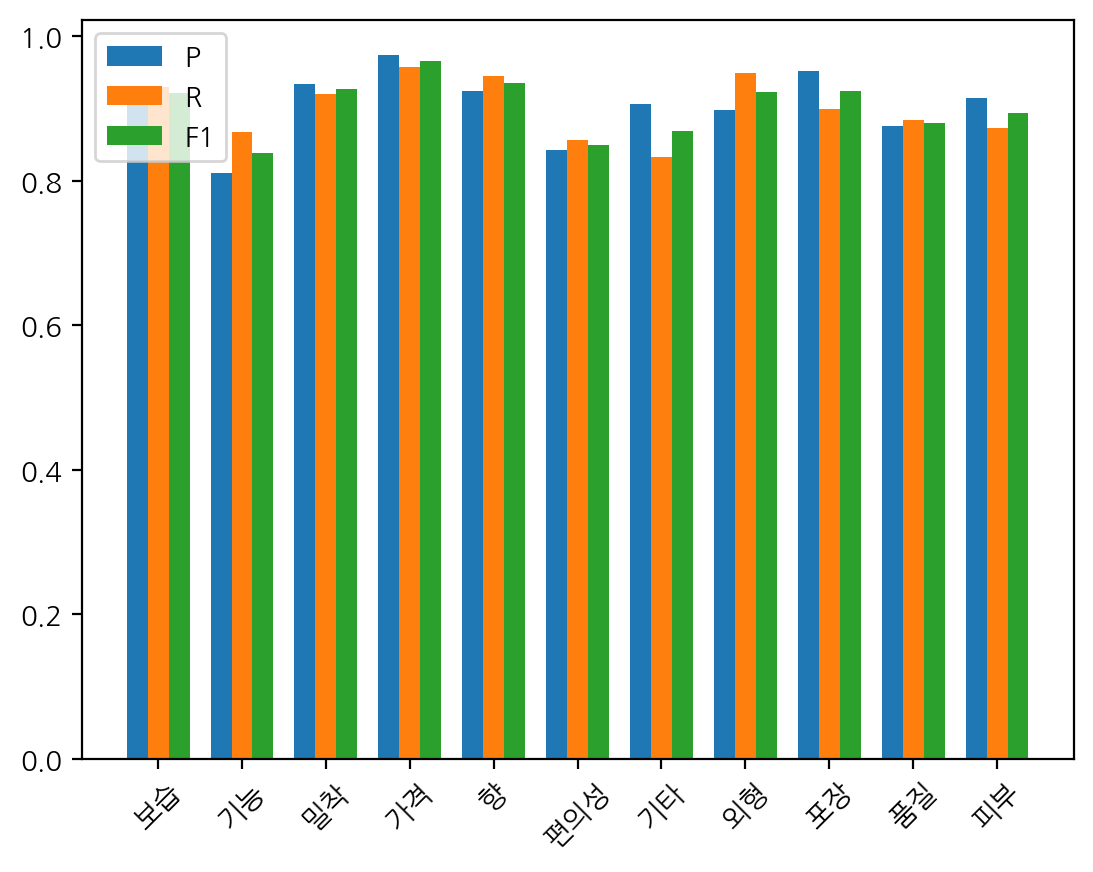

In [27]:
x = np.arange(len(labelz))
plt.bar(x-0.25, precisions, 0.25, label='P')
plt.bar(x, recalls, 0.25, label='R')
plt.bar(x+0.25, f1s, 0.25, label='F1')
plt.xticks(x, labelz, rotation=45)

plt.legend()
plt.show()

## 4.Fine-Tuning2
* LoRA 튜닝하기

### (1) 사전학습 모델 준비
* problem_type="multi_label_classification"

In [28]:
# 모델 로드
base_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels = n)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### (2) LoRA 구성

In [29]:
# LoRA 구성 정의
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # 시퀀스 분류
    r=8,                         # 랭크 값 (작을수록 파라미터 적음)
    lora_alpha=32,               # 너무 작으면 학습 효과 약하고, 너무 크면 발산 위험
    lora_dropout=0.1,
    target_modules=["query", "value", "key"],  # DistilBERT에서 사용되는 attention 레이어 이름
    bias="none"                 # bias는 학습하지 않음
)

# LoRA 적용 (일부 레이어만 학습)
model = get_peft_model(base_model, lora_config)

### (3) 학습 설정

* TrainArguments
    * 일반 파인 튜닝보다는 학습률을 조금 높게 설정

In [30]:
# TrainingArguments 설정
training_args_lora = TrainingArguments(
    output_dir = "./finetune_label_LoRA_results",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 5e-5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 32,
    num_train_epochs = 10,
    weight_decay = 0.02,
    load_best_model_at_end = True,
    logging_dir = "./finetune_label_LoRA_logs",
    logging_steps = 10,
    report_to = "tensorboard"
)

* Trainer

In [31]:
# 사용자 정의 data_collator 생
from torch.utils.data import DataLoader
from transformers import default_data_collator

def float_label_collator(features):
    batch = default_data_collator(features)
    batch["labels"] = batch["labels"].float()
    return batch


In [32]:
# Trainer 설정
trainer_lora = Trainer(
    model=model,
    args=training_args_lora,
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    data_collator=float_label_collator,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)],
)

/tmp/ipython-input-1771693223.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_lora = Trainer(


### (4) 학습

In [33]:
trainer_lora.train()

Epoch,Training Loss,Validation Loss
1,0.486300,0.488975
2,0.436000,0.424810
3,0.387300,0.383234
4,0.365200,0.356536
5,0.338700,0.337456
6,0.337000,0.322174
7,0.321900,0.310760
8,0.315900,0.304908
9,0.286800,0.299512
10,0.306200,0.298069


TrainOutput(global_step=2190, training_loss=0.3692540568303844, metrics={'train_runtime': 1284.8163, 'train_samples_per_second': 54.482, 'train_steps_per_second': 1.705, 'total_flos': 4629052001280000.0, 'train_loss': 0.3692540568303844, 'epoch': 10.0})

### (5) 모델 검증평가

In [34]:
eval_results_lora = trainer_lora.evaluate()
print(f"Evaluation results: {eval_results_lora}")

Evaluation results: {'eval_loss': 0.29806867241859436, 'eval_runtime': 21.8063, 'eval_samples_per_second': 137.575, 'eval_steps_per_second': 4.311, 'epoch': 10.0}


In [35]:
# 예측값
pred_out = trainer.predict(val_ts)
probs = 1 / (1 + np.exp(-pred_out.predictions))
pred = (probs >= 0.5).astype(int)
# 실제값
true = val_ts['label']
# 평가
precisions, recalls, f1s, supports = precision_recall_fscore_support(
    true, pred, average=None, zero_division=0)

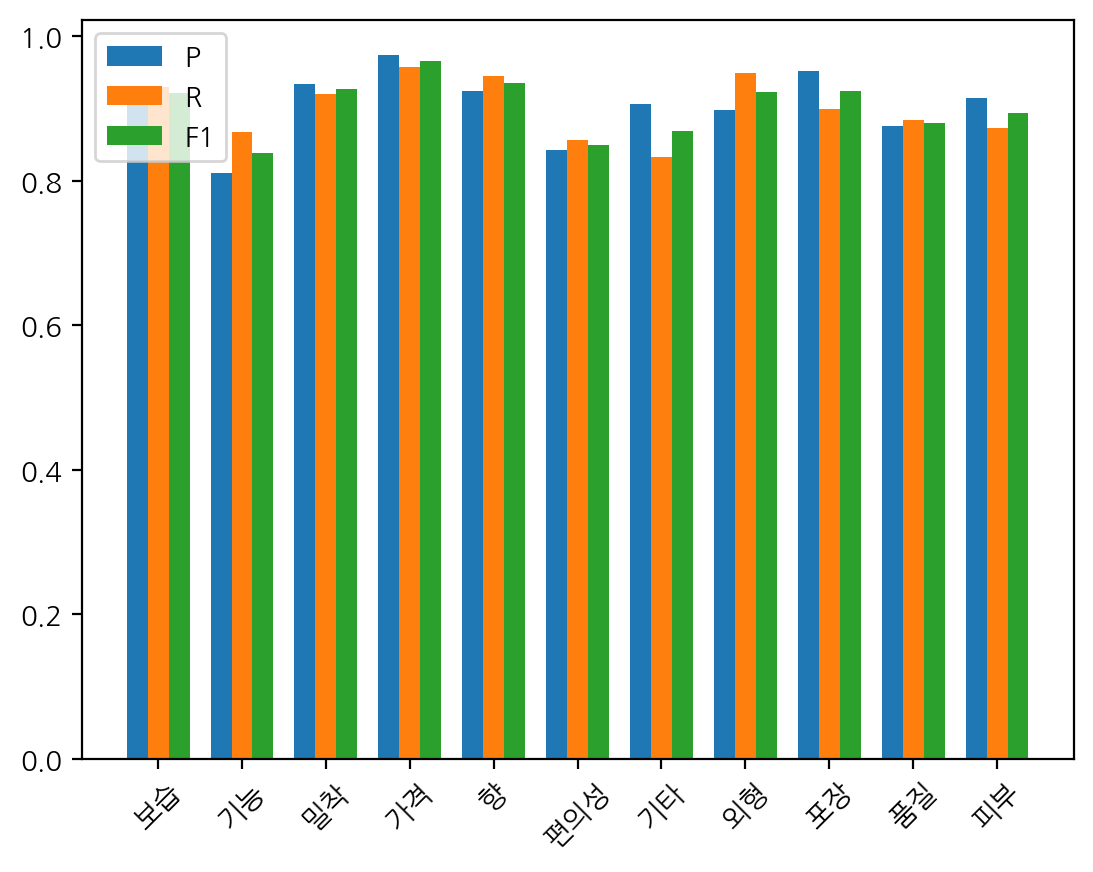

In [36]:
x = np.arange(len(labelz))
plt.bar(x-0.25, precisions, 0.25, label='P')
plt.bar(x, recalls, 0.25, label='R')
plt.bar(x+0.25, f1s, 0.25, label='F1')
plt.xticks(x, labelz, rotation=45)

plt.legend()
plt.show()